# 03 - Differential expression, marker-based annotation, enrichment

Week 3 deliverable. Builds on notebook 02's 26 Leiden clusters. Per the
project's integrity rules: clusters get provisional, hedged labels based on
marker-gene scoring ("enriched for X-associated markers"), never a hard
cell-type or nevus/melanoma claim - and every score is reported alongside
its runner-up so a thin margin is visible, not hidden.

Scope: (1) exclude the 3 batch-flagged clusters from biological
interpretation (decided in notebook 02, applied here), (2) differential
expression per cluster, (3) score clusters against canonical skin/immune
marker panels, (4) cross-check against the published nevus-vs-melanoma
signature (Supplementary Table S4) as an *external prior*, not a
re-discovery - we don't have per-spot nevus/melanoma labels, so this is
"does an independently-found cluster line up with a signature the original
authors published", not "find nevus vs melanoma in this data", (5) pathway
enrichment (Hallmark/Reactome/GO) on each cluster's marker genes.


In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import matplotlib.pyplot as plt
import gseapy as gp

sys.path.insert(0, str(Path("..") / "src"))

RAW = Path("..") / "data" / "raw"
TABLES_OUT = Path("..") / "results" / "tables"
FIGURES_OUT = Path("..") / "results" / "figures"
PROCESSED_OUT = Path("..") / "data" / "processed"

sc.settings.verbosity = 1
plt.rcParams["figure.facecolor"] = "white"
warnings.filterwarnings("ignore", category=FutureWarning)


## 1. Load notebook 02's output, exclude the batch-flagged clusters

The flagged set is read back from `cluster_library_patient_purity.csv`
(the same >80%-one-library rule used in notebook 02), not re-typed by hand,
so this notebook can't silently drift from what notebook 02 actually
found.

In [2]:
combined = sc.read_h5ad(PROCESSED_OUT / "02_combined_qc_clustered.h5ad")
purity = pd.read_csv(TABLES_OUT / "cluster_library_patient_purity.csv", index_col=0)
flagged_clusters = purity[purity["top_library_frac"] > 0.8].index.tolist()
print(f"Excluding {len(flagged_clusters)} batch-flagged clusters from DE/annotation: {flagged_clusters}")

combined.obs["cluster_reliability"] = np.where(
    combined.obs["cluster"].isin(flagged_clusters), "batch_flagged", "ok")
reliable = combined[combined.obs["cluster_reliability"] == "ok"].copy()
reliable.obs["cluster"] = reliable.obs["cluster"].cat.remove_unused_categories()
print(f"{combined.n_obs} spots total -> {reliable.n_obs} in {reliable.obs['cluster'].nunique()} "
      f"clusters used for DE and annotation below")


Excluding 3 batch-flagged clusters from DE/annotation: ['Cluster 23', 'Cluster 24', 'Cluster 25']


57984 spots total -> 55858 in 23 clusters used for DE and annotation below


## 2. Differential expression (one cluster vs. the rest of the reliable population)

Wilcoxon rank-sum per cluster, standard for scanpy. Compared against the
*reliable* population only, so the excluded batch clusters can't distort
what "the rest" looks like.

In [3]:
%%time
sc.tl.rank_genes_groups(reliable, groupby="cluster", method="wilcoxon", key_added="de")
de_df = sc.get.rank_genes_groups_df(reliable, group=None, key="de")
de_df = de_df.rename(columns={"group": "cluster"})
# the full table is every gene x every cluster (~416k rows, ~33MB) - a regenerable
# working file, not something worth bloating git history with; kept locally only
de_df.to_csv(PROCESSED_OUT / "de_markers_per_cluster_full.csv", index=False)
print(f"wrote data/processed/de_markers_per_cluster_full.csv ({len(de_df)} rows, local-only, gitignored)")


wrote data/processed/de_markers_per_cluster_full.csv (415955 rows, local-only, gitignored)
CPU times: total: 2min 7s
Wall time: 2min 12s


In [4]:
# top significant up-regulated genes per cluster - the actually useful, small
# table, used both as the enrichment input below and committed to the repo
TOP_N = 25
top_markers = (de_df[(de_df["pvals_adj"] < 0.05) & (de_df["logfoldchanges"] > 0)]
               .sort_values(["cluster", "scores"], ascending=[True, False])
               .groupby("cluster").head(TOP_N))
top_markers.to_csv(TABLES_OUT / "de_top_markers_per_cluster.csv", index=False)
top_markers_by_cluster = top_markers.groupby("cluster")["names"].apply(list).to_dict()
n_sig = top_markers.groupby("cluster").size()
print(f"wrote results/tables/de_top_markers_per_cluster.csv ({len(top_markers)} rows)")
print("significant up-markers found (of up to", TOP_N, "requested) per cluster:")
print(n_sig.sort_index().to_string())


wrote results/tables/de_top_markers_per_cluster.csv (457 rows)
significant up-markers found (of up to 25 requested) per cluster:
cluster
Cluster 0      4
Cluster 1     25
Cluster 2     25
Cluster 3     25
Cluster 5     25
Cluster 6     25
Cluster 7     25
Cluster 8     25
Cluster 9     25
Cluster 10    25
Cluster 11     8
Cluster 12     5
Cluster 13    25
Cluster 14    15
Cluster 15    25
Cluster 16    25
Cluster 17    25
Cluster 18    25
Cluster 19    25
Cluster 21    25
Cluster 22    25


## 3. Canonical marker-panel scoring

Small, standard marker sets for the cell types expected in skin/melanoma
tissue - not exhaustive, chosen for being broadly agreed on, not fitted to
this data. Filtered to genes actually present in the 18,085-gene shared
panel (checked, not assumed) before scoring.

In [5]:
marker_sets = {
    "melanocytic": ["MLANA", "PMEL", "TYR", "DCT", "MITF", "S100B"],
    "keratinocyte": ["KRT14", "KRT5", "KRT1", "KRT10"],
    "T_cell": ["CD3D", "CD3E", "CD2"],
    "myeloid": ["CD68", "CD163", "LYZ"],
    "B_plasma": ["CD79A", "MS4A1", "MZB1"],
    "endothelial": ["PECAM1", "VWF"],
    "fibroblast_stroma": ["COL1A1", "COL1A2", "DCN", "LUM"],
    "smooth_muscle": ["ACTA2", "MYH11"],
}
for name, genes in marker_sets.items():
    present = [g for g in genes if g in reliable.var_names]
    missing = [g for g in genes if g not in reliable.var_names]
    if missing:
        print(f"{name}: missing from panel (dropped): {missing}")
    marker_sets[name] = present
    sc.tl.score_genes(reliable, present, score_name=f"score_{name}")

score_cols = [f"score_{name}" for name in marker_sets]
cluster_scores = reliable.obs.groupby("cluster")[score_cols].mean()
cluster_scores.columns = list(marker_sets.keys())
cluster_scores.to_csv(TABLES_OUT / "cluster_marker_panel_scores.csv")
cluster_scores.round(3)


,melanocytic,keratinocyte,T_cell,myeloid,B_plasma,endothelial,fibroblast_stroma,smooth_muscle
cluster,,,,,,,,
Cluster 0,-0.122,0.146,0.000,-0.030,-0.003,-0.042,2.198,0.085
Cluster 1,-0.337,1.612,-0.031,-0.303,-0.022,-0.224,1.193,-0.014
Cluster 2,-0.492,1.102,0.026,-0.162,0.001,0.034,1.891,0.120
Cluster 3,-0.141,0.232,-0.011,-0.096,-0.006,0.085,0.987,0.200
Cluster 4,-0.087,0.141,-0.002,-0.069,-0.003,-0.055,1.827,0.048
Cluster 5,0.758,2.408,-0.033,-0.193,-0.022,-0.461,1.002,-0.269
Cluster 6,1.339,-0.229,-0.035,-0.267,-0.024,-0.347,1.039,-0.117
Cluster 7,0.401,3.471,-0.085,-0.532,-0.040,-0.648,0.215,-0.530
Cluster 8,0.738,-0.247,0.316,0.331,0.160,-0.250,1.176,-0.353


**A problem with the raw scores, caught by looking at the whole table
rather than just each row's top value:** `fibroblast_stroma` scores highly
in almost every cluster (see the table above), not just a few - the panel
isn't distinguishing clusters from each other, it's a near-ubiquitous
background level (plausible reading: Visium spots mix in surrounding dermal
stroma regardless of what else is in the spot, and COL1A1/COL1A2 are
expressed highly enough that even score_genes' expression-matched control
bins don't fully correct for it). Taking the raw per-row top score as a
label would call ~20 of 23 clusters "fibroblast_stroma", which says more
about the panel than about the clusters.

Fix: z-score each panel's column *across clusters* before picking a label.
This asks "is this panel unusually elevated in this cluster relative to its
own typical level across all clusters" rather than "which panel has the
highest raw number" - a panel that's uniformly high (or uniformly near-zero)
everywhere won't win anywhere under this rule, by construction.

In [6]:
panel_cols = list(marker_sets.keys())
print("per-panel spread across clusters (raw scores) - low spread despite a high mean is the tell:")
print(cluster_scores[panel_cols].agg(["mean", "std"]).T.round(3))

z_scores = (cluster_scores[panel_cols] - cluster_scores[panel_cols].mean()) / cluster_scores[panel_cols].std()

def top_with_margin(row, margin=0.5):
    ranked = row.sort_values(ascending=False)
    if ranked.iloc[0] - ranked.iloc[1] < margin:
        return f"ambiguous ({ranked.index[0]} vs {ranked.index[1]})"
    return ranked.index[0]

cluster_scores["provisional_label"] = z_scores.apply(top_with_margin, axis=1)
cluster_scores["provisional_label_z_margin"] = z_scores.apply(
    lambda r: r.sort_values(ascending=False).iloc[0] - r.sort_values(ascending=False).iloc[1], axis=1)
print()
print(cluster_scores[["provisional_label", "provisional_label_z_margin"]].round(2).to_string())


per-panel spread across clusters (raw scores) - low spread despite a high mean is the tell:
                    mean    std
melanocytic       -0.055  0.463
keratinocyte       0.691  1.028
T_cell             0.004  0.076
myeloid           -0.102  0.223
B_plasma           0.004  0.047
endothelial       -0.144  0.268
fibroblast_stroma  1.728  0.778
smooth_muscle      0.127  0.594

                                        provisional_label  provisional_label_z_margin
cluster                                                                              
Cluster 0    ambiguous (fibroblast_stroma vs endothelial)                        0.22
Cluster 1                                    keratinocyte                        1.13
Cluster 2         ambiguous (endothelial vs keratinocyte)                        0.27
Cluster 3                                     endothelial                        0.73
Cluster 4              ambiguous (endothelial vs myeloid)                        0.19
Cluster 5        

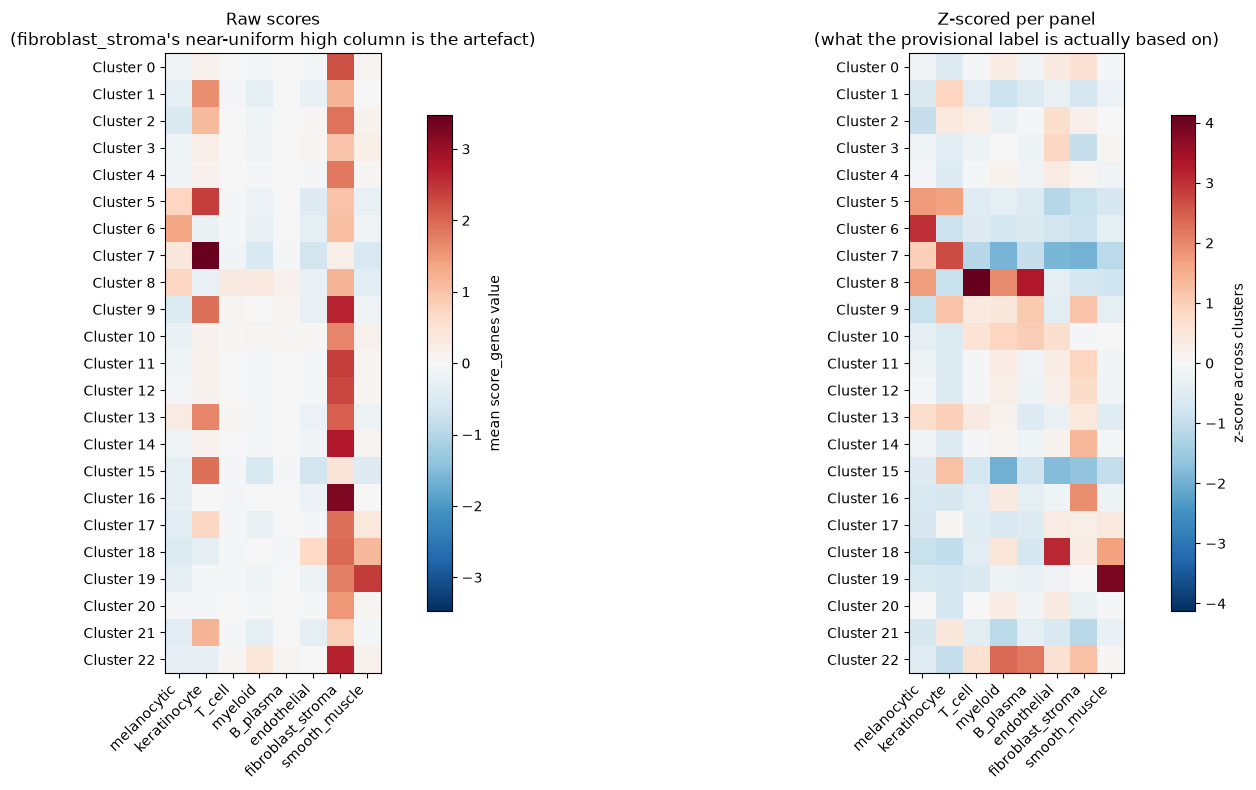

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(17, 8))
raw_vals = cluster_scores[panel_cols].values
im0 = axes[0].imshow(raw_vals, cmap="RdBu_r", vmin=-np.abs(raw_vals).max(), vmax=np.abs(raw_vals).max())
axes[0].set_xticks(range(len(panel_cols)), labels=panel_cols, rotation=45, ha="right")
axes[0].set_yticks(range(len(cluster_scores)), labels=cluster_scores.index)
plt.colorbar(im0, ax=axes[0], label="mean score_genes value", shrink=0.8)
axes[0].set_title("Raw scores\n(fibroblast_stroma's near-uniform high column is the artefact)")

z_vals = z_scores.values
im1 = axes[1].imshow(z_vals, cmap="RdBu_r", vmin=-np.abs(z_vals).max(), vmax=np.abs(z_vals).max())
axes[1].set_xticks(range(len(panel_cols)), labels=panel_cols, rotation=45, ha="right")
axes[1].set_yticks(range(len(cluster_scores)), labels=cluster_scores.index)
plt.colorbar(im1, ax=axes[1], label="z-score across clusters", shrink=0.8)
axes[1].set_title("Z-scored per panel\n(what the provisional label is actually based on)")
plt.tight_layout()
plt.savefig(FIGURES_OUT / "03_cluster_marker_panel_heatmap.png", dpi=150)
plt.show()


## 4. Cross-check against the published nevus/melanoma signature (external prior)

Supplementary Table S4 lists ~1,976 genes differentially expressed between
nevus and "melanoma 1" spots *in the original authors' own spot-level
labels*, which we don't have. Using it here to score independently-derived
clusters is a legitimate external check; using it to *define* nevus/melanoma
groups in this data would be circular, since the signature itself came from
this dataset. Only the former is done below.

In [8]:
s4 = pd.read_excel(RAW / "supplementary" / "can-25-2934_supplementary_tables_suppst1.xlsx",
                    sheet_name="Supplementary Table S4", header=2)
N = 50
nevus_associated = s4.sort_values("avg_log2FC").head(N)["Gene"].tolist()
melanoma_associated = s4.sort_values("avg_log2FC", ascending=False).head(N)["Gene"].tolist()
nevus_associated = [g for g in nevus_associated if g in reliable.var_names]
melanoma_associated = [g for g in melanoma_associated if g in reliable.var_names]
print(f"nevus-associated genes usable ({len(nevus_associated)}/{N} present in our panel)")
print(f"melanoma-associated genes usable ({len(melanoma_associated)}/{N} present in our panel)")

sc.tl.score_genes(reliable, nevus_associated, score_name="score_nevus_associated")
sc.tl.score_genes(reliable, melanoma_associated, score_name="score_melanoma_associated")
s4_scores = reliable.obs.groupby("cluster")[["score_nevus_associated", "score_melanoma_associated"]].mean()
print("raw score means across clusters (same ubiquity check as section 3):")
print(s4_scores.agg(["mean", "std"]).round(3).to_string())


nevus-associated genes usable (50/50 present in our panel)
melanoma-associated genes usable (50/50 present in our panel)


raw score means across clusters (same ubiquity check as section 3):
      score_nevus_associated  score_melanoma_associated
mean                   0.093                     -0.028
std                    0.078                      0.025


Same pattern as `fibroblast_stroma` in section 3: `score_nevus_associated`
is positive in nearly every cluster and `score_melanoma_associated` is
negative in nearly every cluster - a systematic shift, not a per-cluster
signal. Directly comparing the two raw scores would call ~20 of 23 clusters
"nevus-associated" for the same reason ~20 were called "fibroblast_stroma" -
so the same z-scoring-across-clusters fix applies here.

In [9]:
s4_z = (s4_scores - s4_scores.mean()) / s4_scores.std()
s4_scores["skews_toward"] = np.where(
    s4_z["score_melanoma_associated"] > s4_z["score_nevus_associated"],
    "melanoma-M1-associated", "nevus-associated")
s4_scores["skew_z_margin"] = (s4_z["score_melanoma_associated"] - s4_z["score_nevus_associated"]).abs()
s4_scores.to_csv(TABLES_OUT / "cluster_nevus_melanoma_signature_scores.csv")
s4_scores.round(3)


,score_nevus_associated,score_melanoma_associated,skews_toward,skew_z_margin
cluster,,,,
Cluster 0,0.073,-0.016,melanoma-M1-associated,0.744
Cluster 1,0.063,-0.019,melanoma-M1-associated,0.768
Cluster 2,0.199,-0.072,nevus-associated,3.150
Cluster 3,0.079,-0.016,melanoma-M1-associated,0.663
Cluster 4,0.051,-0.012,melanoma-M1-associated,1.189
Cluster 5,-0.001,0.006,melanoma-M1-associated,2.597
Cluster 6,0.329,-0.067,nevus-associated,4.641
Cluster 7,-0.050,-0.011,melanoma-M1-associated,2.547
Cluster 8,0.009,0.011,melanoma-M1-associated,2.669


## 5. Pathway enrichment (Hallmark, Reactome, GO Biological Process)

In [10]:
%%time
GENE_SETS = ["MSigDB_Hallmark_2020", "Reactome_Pathways_2024", "GO_Biological_Process_2025"]
enrichment_rows = []
for cluster, genes in sorted(top_markers_by_cluster.items()):
    if len(genes) < 5:
        print(f"{cluster}: skipped (only {len(genes)} significant markers, too few for enrichment)")
        continue
    try:
        res = gp.enrichr(gene_list=genes, gene_sets=GENE_SETS, outdir=None)
        top = res.results.sort_values("Adjusted P-value").head(5).copy()
        top.insert(0, "cluster", cluster)
        enrichment_rows.append(top)
        print(f"{cluster}: {len(genes)} genes -> top hit "
              f"{top.iloc[0]['Gene_set']}/{top.iloc[0]['Term']} (adj p={top.iloc[0]['Adjusted P-value']:.2e})")
    except Exception as e:
        print(f"{cluster}: enrichment FAILED ({type(e).__name__}: {e}) - skipped, not faked")

if enrichment_rows:
    enrichment_df = pd.concat(enrichment_rows, ignore_index=True)
    enrichment_df.to_csv(TABLES_OUT / "cluster_pathway_enrichment_top5.csv", index=False)
    print(f"\nwrote results/tables/cluster_pathway_enrichment_top5.csv ({len(enrichment_df)} rows)")
else:
    enrichment_df = pd.DataFrame()
    print("\nno enrichment results obtained for any cluster")


Cluster 0: skipped (only 4 significant markers, too few for enrichment)


Cluster 1: 25 genes -> top hit Reactome_Pathways_2024/Formation of the Cornified Envelope (adj p=4.86e-23)


Cluster 10: 25 genes -> top hit GO_Biological_Process_2025/Antimicrobial Humoral Response (GO:0019730) (adj p=4.28e-04)


Cluster 11: 8 genes -> top hit Reactome_Pathways_2024/ECM Proteoglycans (adj p=3.23e-09)


Cluster 12: 5 genes -> top hit MSigDB_Hallmark_2020/Epithelial Mesenchymal Transition (adj p=8.56e-10)


...

Cluster 5: 25 genes -> top hit Reactome_Pathways_2024/Formation of the Cornified Envelope (adj p=2.42e-08)


Cluster 6: 25 genes -> top hit Reactome_Pathways_2024/FASTK Family Proteins Regulate Processing and Stability of Mitochondrial RNAs (adj p=8.03e-12)


Cluster 7: 25 genes -> top hit Reactome_Pathways_2024/Formation of the Cornified Envelope (adj p=3.32e-23)


Cluster 8: 25 genes -> top hit MSigDB_Hallmark_2020/Allograft Rejection (adj p=5.94e-08)


Cluster 9: 25 genes -> top hit Reactome_Pathways_2024/Collagen Degradation (adj p=5.29e-15)

wrote results/tables/cluster_pathway_enrichment_top5.csv (100 rows)
CPU times: total: 9.22 s
Wall time: 1min 4s


## 6. Cluster annotation summary

One row per reliable cluster: size, provisional marker-panel label (with its
margin over the runner-up, so a thin call is visible), the nevus/melanoma
signature skew, and the top enriched pathway if one was found. This is the
table to read *with* the fuller ones above, not instead of them - it
compresses three separate analyses into one line per cluster.

In [11]:
summary_rows = []
for cl in reliable.obs["cluster"].cat.categories:
    row = cluster_scores.loc[cl]
    s4_row = s4_scores.loc[cl]
    top_pathway = None
    if not enrichment_df.empty:
        cl_hits = enrichment_df[enrichment_df["cluster"] == cl]
        if len(cl_hits):
            top_pathway = f"{cl_hits.iloc[0]['Term']} ({cl_hits.iloc[0]['Gene_set']})"
    summary_rows.append({
        "cluster": cl,
        "n_spots": int((reliable.obs["cluster"] == cl).sum()),
        "provisional_marker_label": row["provisional_label"],
        "label_z_margin": round(float(row["provisional_label_z_margin"]), 2),
        "nevus_melanoma_signature_skew": s4_row["skews_toward"],
        "skew_z_margin": round(float(s4_row["skew_z_margin"]), 2),
        "top_enriched_pathway": top_pathway,
        "n_significant_markers": int(n_sig.get(cl, 0)),
    })
cluster_annotation_summary = pd.DataFrame(summary_rows).set_index("cluster")
cluster_annotation_summary.to_csv(TABLES_OUT / "cluster_annotation_summary.csv")
cluster_annotation_summary


,n_spots,provisional_marker_label,label_z_margin,nevus_melanoma_signature_skew,skew_z_margin,top_enriched_pathway,n_significant_markers
cluster,,,,,,,
Cluster 0,2042,ambiguous (fibroblast_stroma vs endothelial),0.22,melanoma-M1-associated,0.74,NaN,4
Cluster 1,2283,keratinocyte,1.13,melanoma-M1-associated,0.77,Formation of the Cornified Envelope (Reactome_...,25
Cluster 2,1734,ambiguous (endothelial vs keratinocyte),0.27,nevus-associated,3.15,Linoleic Acid (LA) Metabolism (Reactome_Pathwa...,25
Cluster 3,2460,endothelial,0.73,melanoma-M1-associated,0.66,Epigenetic Regulation of Gene Expression by ML...,25
Cluster 4,2450,ambiguous (endothelial vs myeloid),0.19,melanoma-M1-associated,1.19,NaN,0
Cluster 5,3934,ambiguous (melanocytic vs keratinocyte),0.09,melanoma-M1-associated,2.60,Formation of the Cornified Envelope (Reactome_...,25
Cluster 6,1861,melanocytic,3.42,nevus-associated,4.64,FASTK Family Proteins Regulate Processing and ...,25
Cluster 7,4148,keratinocyte,1.72,melanoma-M1-associated,2.55,Formation of the Cornified Envelope (Reactome_...,25
Cluster 8,2224,T_cell,0.82,melanoma-M1-associated,2.67,Allograft Rejection (MSigDB_Hallmark_2020),25


In [12]:
combined.write_h5ad(PROCESSED_OUT / "03_annotated.h5ad")
print("wrote data/processed/03_annotated.h5ad")


wrote data/processed/03_annotated.h5ad


## 7. Summary - observed / inferred / hypothesised kept separate

**Observed (direct output of the computations above, in the saved tables):**
- DE was computed for all 23 reliable clusters against the reliable
  population (full table: `data/processed/de_markers_per_cluster_full.csv`,
  regenerable, not committed; top significant markers:
  `results/tables/de_top_markers_per_cluster.csv`)
- Each cluster's canonical-marker-panel scores and nevus/melanoma-signature
  scores are in `cluster_marker_panel_scores.csv` and
  `cluster_nevus_melanoma_signature_scores.csv`
- Pathway enrichment results (where the API returned any) are in
  `cluster_pathway_enrichment_top5.csv`

**Inferred (this notebook's judgment calls, stated as such, not fact):**
- `provisional_marker_label` per cluster - a hedged read of the
  *z-scored-across-clusters* panel scores, not the raw scores. The raw
  scores were checked first and rejected as a basis for labelling: both
  `fibroblast_stroma` (section 3) and `score_nevus_associated` (section 4)
  came back positive in ~90% of clusters at similar magnitude, which is a
  ubiquitous background level, not something that distinguishes one cluster
  from another - using the raw numbers would have mislabelled most of the
  dataset as stroma/nevus by conflating "high everywhere" with
  "specifically high here". Z-scoring each panel across clusters before
  picking a label corrects for that.
- `nevus_melanoma_signature_skew` - which published signature a cluster's
  *z-scored* expression leans toward; not a claim that the cluster *is*
  nevus or melanoma tissue, and several clusters have a small
  `skew_z_margin` (near-tied) rather than a confident skew

**Hypothesised (worth checking further, not established by this notebook):**
Cluster 6 - the strongest melanocytic-marker signal in the dataset
(z-margin 3.42) - skews toward the *nevus*-associated signature (z-margin
4.64), while Cluster 8 - the strongest immune/T-cell signal (z-margin 0.82)
- skews toward the *melanoma*-associated signature (z-margin 2.67). A benign
melanocytic population reading as more nevus-like, and immune infiltration
reading as more melanoma-like, would both be consistent with the biology the
source paper describes - but this is two data points, not a validated
pattern, and it's exactly the kind of thing that has to hold up under
spatial context (notebook 04) before it means anything.

**Explicitly not claimed:**
- No mutation calls, no diagnostic/clinical statements, and the 3
  batch-flagged clusters from notebook 02 are excluded here, not
  reinterpreted as biology.

**Carried into notebook 04 (spatial statistics) and beyond:** read
`cluster_annotation_summary.csv` together with the full score tables before
using any cluster label downstream - a one-line summary always loses the
margin information that makes a label trustworthy or not.